<a href="https://colab.research.google.com/github/azhgh22/Monet_Style_Generator/blob/main/notebooks/run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Set Env**

In [1]:
%%capture
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
user_name = userdata.get('GITHUB_USERNAME')
mail = userdata.get('GITHUB_MAIL')

!git config --global user.name "{user_name}"
!git config --global user.email "{mail}"
!git clone https://{token}@github.com/azhgh22/Monet_Style_Generator.git

# **Imports**

In [33]:
import sys
import os
import torch

# Add the root directory of the cloned repository to the Python path
sys.path.append('/content/Monet_Style_Generator')

import importlib
import utils.custom_dataset as custom_dataset_module
import utils.train_test_split as tts_module
import utils.dataset_assembly as ds_assembly_module
import utils.weight_initializer as weight_initializer
importlib.reload(custom_dataset_module)
importlib.reload(tts_module)
importlib.reload(ds_assembly_module)
importlib.reload(weight_initializer)
from utils.custom_dataset import CustomDataset
from utils.dataset_assembly import DatasetAssembly
from utils.train_test_split import TrainTestSplit
from utils.weight_initializer import WeightsInitializer
from pathlib import Path
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# **Read Data and Split data**

In [3]:
train, val, test = TrainTestSplit("/content/Monet_Style_Generator/data/photo_jpg/").split(0.7,0.15,0.15)

In [4]:
monet_pictures = list(Path("/content/Monet_Style_Generator/data/monet_jpg/").glob('*.jpg'))

In [6]:
# create datasets
train_part = CustomDataset(train)
val_dataset = CustomDataset(val)
test_dataset = CustomDataset(test)

monet_dataset = CustomDataset(monet_pictures)

train_dataset = DatasetAssembly(train_part, monet_dataset)

In [7]:

import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torchvision.utils import make_grid

def show_img(x: torch.Tensor):
  x = x.detach().cpu()
  x = x.permute(1, 2, 0)

  plt.imshow(x)
  plt.axis("off")
  plt.show()

# **Data Loaders**

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
)

val_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True,
  )

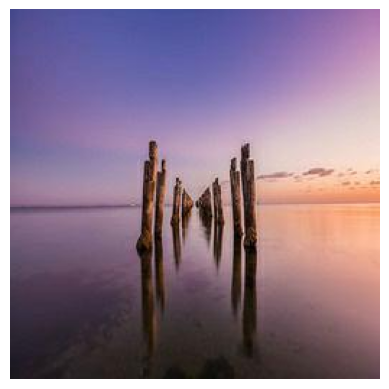

In [9]:
show_img(train_dataset[0][0])

In [34]:
import models.GAN.generator_models.resnet_gen as res_gen
import models.GAN.discriminator_models.patchgan as patchgan
import models.GAN.cycle_gan as cycle_gan
importlib.reload(res_gen)
importlib.reload(patchgan)
importlib.reload(cycle_gan)
from models.GAN.generator_models.resnet_gen import ResnetGenerator
from models.GAN.discriminator_models.patchgan import PatchGANDiscriminator
from models.GAN.cycle_gan import CycleGAN

# **Train Loop**

In [35]:
EPOCHS = 200

monet_generator = ResnetGenerator()
monet_discriminator = PatchGANDiscriminator()

picture_generator = ResnetGenerator()
picture_discriminator = PatchGANDiscriminator()

model = CycleGAN(monet_generator, picture_generator, monet_discriminator, picture_discriminator)
model.state_dict()
## init model weights from Normal (0, 0.002)
wi = WeightsInitializer()
model.apply(wi)

model.echo_step()
# for e in range(EPOCHS):
#   for p, m in train_loader:
#       p = p.to(device)
#       m = m.to(device)

#       model.train_step()

#   model.epoch_step()



CycleGAN(
  (G_AB): ResnetGenerator(
    (model): Sequential(
      (0): ReflectionPad2d((3, 3, 3, 3))
      (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
      (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (3): ReLU(inplace=True)
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (9): ReLU(inplace=True)
      (10): ResidualBlock(
        (block): Sequential(
          (0): ReflectionPad2d((1, 1, 1, 1))
          (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
          (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          (3): ReLU(inplace=Tru